# 공공 자전거 미반납 예측

In [ ]:
# 준비
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

plt.rcParams["font.family"] = "Malgun Gothic"  
plt.rcParams["axes.unicode_minus"] = False

LIMIT = 100         
COST_FN = 300000     
COST_FP = 2000       

## [STEP 1] 파생변수 생성 및 정답지(Target) 만들기

### 요구사항

`clean_rentals.csv`를 불러온 뒤 아래 파생변수들을 만드세요.

1. **대여 시간(분)**: `duration_min = return_time - rent_time` 의 분 단위 계산
2. **`is_overdue_100m` (예측 대상)**: 대여 시간(`duration_min`)이 100분(1시간 40분)을 초과하면 `1`, 아니면 `0`
3. 대여 시점(`rent_time`) 기준 **시간대(hour)** 와 **요일** 추출
- 전체 행 수와 **`is_overdue_100m` 의 비율**을 확인하세요.
- **"전부 정상(미반납 아님)"이라고 답할 때의 정확도**를 계산하세요. 담당자가 말한 "정확도 84%"의 정체가 바로 이것입니다.

In [2]:
# STEP 1
df = pd.read_csv("clean_rentals.csv", parse_dates=["rent_time", "return_time"])

df["duration_min"] = (df["return_time"] - df["rent_time"]).dt.total_seconds() / 60
df["target"] = (df["duration_min"] > LIMIT).astype(int)  
df["hour"] = df["rent_time"].dt.hour
df["weekday"] = df["rent_time"].dt.dayofweek

print("전체 행 수:", len(df))
print(df["target"].value_counts())
ratio = df["target"].mean()
print("미반납 비율:", round(ratio, 4))
print("전부 정상이라고 답할 때 정확도:", round(1 - ratio, 4))

전체 행 수: 13501
target
0    11136
1     2365
Name: count, dtype: int64
미반납 비율: 0.1752
전부 정상이라고 답할 때 정확도: 0.8248


## [STEP 2] 결합 및 사용자 파생변수

### 요구사항

- 대여 기록에 `users.csv` 를 결합하세요. (`how` 와 `validate` 명시)
- **결합 전후 행 수를 비교**하여 중복이 발생하지 않았는지 확인하세요.
- `join_date` 와 `rent_time` 을 활용해, 대여 시점 기준 **유저의 가입 기간(일)** 파생변수를 만드세요.

In [3]:
# STEP 2
users = pd.read_csv("users.csv")
users["join_date"] = pd.to_datetime(users["join_date"])

before = len(df)
df = df.merge(users, on="user_id", how="left", validate="many_to_one")
print("합치기 전/후:", before, len(df))

df["tenure"] = (df["rent_time"] - df["join_date"]).dt.days
print("가입일보다 대여일이 빠른 행:", (df["tenure"] < 0).sum())
df["tenure"] = df["tenure"].clip(lower=0)  

합치기 전/후: 13501 13501
가입일보다 대여일이 빠른 행: 6160


## [STEP 3] 데이터 누수 탐지

**이 단계가 이 문제의 첫 번째 관문입니다.**

지금 데이터프레임 안에는 **모델에 넣으면 안 되는 컬럼**이 섞여 있습니다.
학습 시점(대여 시점)에는 절대 알 수 없는 정보, 즉 **결과가 나온 뒤(반납 시점)에야 확정되는 값**들입니다.

### 요구사항

1. 각 컬럼들을 살펴보고 `is_overdue_100m` 와 직결되어 있는 누수(Leakage) 컬럼을 모두 찾아내세요.
2. 의심스러운 컬럼들을 찾고, **왜 학습에 쓰면 안 되는지** 설명하세요.

<aside>
💡

**판단 기준**

“이 값은 **언제** 확정되는가?”를 기준으로 판단해보세요.

우리는 사용자가 자전거를 **빌려가는 순간(`rent_time`)**에 미반납 여부를 예측해야 합니다. 그 시점에 알 수 없는 값(ex. 주행 거리)이 포함되어 있다면 모두 누수로 판단하면 됩니다.

</aside>

**리포트에 반드시 쓸 것**

- 제거한 컬럼 이름들 (최소 3개 이상)
- 그 값이 **언제** 확정되는지
- 그대로 학습하면 실제 운영에서 무슨 일이 벌어지는지

In [4]:
# STEP 3
leak_cols = ["return_time", "duration_min", "fee", "distance_km"]
print(df.columns.tolist())
print("누수 컬럼:", leak_cols)

['rental_id', 'bike_id', 'user_id', 'rent_time', 'return_time', 'distance_km', 'fee', 'payment_method', 'station_id', 'bike_type', 'gear_count', 'manufacture_year', 'daily_fee', 'station_name', 'district', 'duration_min', 'target', 'hour', 'weekday', 'join_date', 'membership_type', 'tenure']
누수 컬럼: ['return_time', 'duration_min', 'fee', 'distance_km']


## [STEP 4] 학습, 테스트 분할

### 요구사항

- **시점(`rent_time`) 기준**으로 분할하세요. 상위 80% 날짜를 기준선으로 삼습니다.
- 범주형 변수(`payment_method`, `membership_type` 등)를 인코딩하세요.
- **테스트 세트의 열 구성을 학습 세트에 맞추세요.**

<aside>
⚠️

**랜덤 분할을 쓰면 안 됩니다.**

시계열 데이터에서 랜덤 분할을 쓰면, 미래의 패턴으로 과거를 예측하는 오류를 범하게 됩니다.

</aside>

In [ ]:
# STEP 4
cut = df["rent_time"].quantile(0.8)
train = df[df["rent_time"] <= cut]
test = df[df["rent_time"] > cut]
print("기준 시각:", cut, "| train/test:", len(train), len(test))

features = ["hour", "weekday", "tenure", "payment_method", "membership_type"]

X_train = pd.get_dummies(train[features])
X_test = pd.get_dummies(test[features])
X_test = X_test.reindex(columns=X_train.columns, fill_value=0) 

y_train = train["target"]
y_test = test["target"]

기준 시각: 2022-10-20 16:21:00 | train/test: 10801 2700


## [STEP 5] 누수의 위력 확인

STEP 3에서 찾은 컬럼 중 하나(예: `fee` 또는 `duration_min`)를 **일부러 넣어서** 학습해 보세요.

### 요구사항

`RandomForestClassifier` 로 두 번 학습하고 비교하세요.

1. 누수 컬럼을 모두 **제거한** 피처
2. 누수 컬럼을 **포함한** 피처

정확도, 재현율, F1, AUC 를 나란히 놓고 비교합니다. 누수 컬럼이 포함되었을 때 모델 성능이 비정상적으로 완벽해지는지 확인하세요.

In [ ]:
# STEP 5
X_train_leak = X_train.copy()
X_test_leak = X_test.copy()
X_train_leak["duration_min"] = train["duration_min"]
X_train_leak["fee"] = train["fee"]
X_test_leak["duration_min"] = test["duration_min"]
X_test_leak["fee"] = test["fee"]

step5 = {}
for name, Xtr, Xte in [("누수 제거", X_train, X_test), ("누수 포함", X_train_leak, X_test_leak)]:
    model = RandomForestClassifier(n_estimators=200, random_state=42)
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    step5[name] = [accuracy_score(y_test, pred), precision_score(y_test, pred, zero_division=0),
                   recall_score(y_test, pred), f1_score(y_test, pred), roc_auc_score(y_test, proba)]

print(pd.DataFrame(step5, index=["정확도", "정밀도", "재현율", "F1", "AUC"]).T.round(4))

          정확도     정밀도     재현율      F1     AUC
누수 제거  0.7748  0.1629  0.0594  0.0871  0.4973
누수 포함  1.0000  1.0000  1.0000  1.0000  1.0000


## [STEP 6] 모델 비교

누수를 완벽히 제거한 피처(대여 시점에 알 수 있는 정보만 남김)로 여러 모델을 학습하고 비교하세요.

### 요구사항

아래 다섯 가지를 학습하고 **정확도, 정밀도, 재현율, F1, AUC** 를 표로 정리하세요.

| 모델 | 비고 |
| --- | --- |
| `DummyClassifier` | 베이스라인 |
| `LogisticRegression` | 스케일링 필요 |
| `LogisticRegression(class_weight="balanced")` | - |
| `RandomForest` | 스케일링 불필요 |
| `RandomForest(class_weight="balanced")` | - |

### 확인 문항

1. `DummyClassifier` 와 `RandomForest` 의 정확도가 거의 똑같습니다. 무슨 일이 일어난 걸까요?
2. 담당자가 말한 "정확도 84%인데 연체를 못 잡는다"가 어느 상황에 해당하나요?
3. `class_weight="balanced"` 를 넣으면 정확도가 **떨어집니다.** 그런데도 왜 불균형 데이터에서는 이 옵션을 써야 하나요?

In [ ]:
# STEP 6
scaler = StandardScaler()  
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# (이름, 모델, 학습용 X, 테스트용 X)
model_list = [
    ("Dummy", DummyClassifier(strategy="most_frequent"), X_train, X_test),
    ("LogReg", LogisticRegression(max_iter=1000), X_train_s, X_test_s),
    ("LogReg(balanced)", LogisticRegression(max_iter=1000, class_weight="balanced"), X_train_s, X_test_s),
    ("RF", RandomForestClassifier(n_estimators=200, random_state=42), X_train, X_test),
    ("RF(balanced)", RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"), X_train, X_test),
]

step6 = {}
for name, model, Xtr, Xte in model_list:
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    proba = model.predict_proba(Xte)[:, 1]
    step6[name] = [accuracy_score(y_test, pred), precision_score(y_test, pred, zero_division=0),
                   recall_score(y_test, pred), f1_score(y_test, pred), roc_auc_score(y_test, proba)]

print(pd.DataFrame(step6, index=["정확도", "정밀도", "재현율", "F1", "AUC"]).T.round(4))

                     정확도     정밀도     재현율      F1     AUC
Dummy             0.8193  0.0000  0.0000  0.0000  0.5000
LogReg            0.8193  0.0000  0.0000  0.0000  0.4876
LogReg(balanced)  0.4667  0.1805  0.5512  0.2720  0.4878
RF                0.7748  0.1629  0.0594  0.0871  0.4973
RF(balanced)      0.6607  0.1916  0.2725  0.2250  0.5005


## [STEP 7] 혼동행렬과 지표

### 요구사항

`RandomForest(balanced)` 의 혼동행렬을 구하고 **TP, FN, FP, TN 을 각각 자전거 도메인 관점에서 해석**하세요.

### 확인 문항

이 문제에서 **FN(연체를 놓침) 과 FP(정상을 연체로 예측) 중 어느 쪽이 치명적인가요?** 근거와 함께 정리해주세요.

In [ ]:
# STEP 7
rf = model_list[4][1]
proba_test = rf.predict_proba(X_test)[:, 1]
pred = rf.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
print("TP =", tp, "FN =", fn, "FP =", fp, "TN =", tn)

TP = 133 FN = 355 FP = 561 TN = 1651


## [STEP 8] 비용 기반 임계값 선택

**이 단계가 이 문제의 핵심입니다.**

운영팀에서 예측 오류에 따른 비용(손실) 정보를 알려줬습니다.

| 상황 | 비용 | 설명 |
| --- | --- | --- |
| **FN** (장기 연체를 놓침) | **15,000원** | 방치 자전거 회수 인건비 및 미수납 연체료 손실 |
| **FP** (정상인데 엄한 사람 의심) | **2,000원** | 이용자에게 반납 독촉 전화/문자 발송 및 고객 불만 CS 리소스 |

### 요구사항

1. 임계값을 `0.05` 부터 `0.95` 까지 `0.05` 간격으로 바꿔가며 아래를 계산하세요.
    - TP, FN, FP, 재현율, 정밀도
    - **총비용 = FN × 15,000 + FP × 2,000**
2. **총비용이 최소가 되는 임계값**을 찾으세요.
3. 아무 예측도 하지 않았을 때(= 전부 정상 예측으로 간주하여 연체 비용을 고스란히 떠안을 때)의 비용과 비교해 **절감액**을 계산하세요.

<aside>
⚠️

**F1 최대가 정답이 아닙니다.**

비용이 비대칭적일 때는 균형(F1)이 아니라 **총비용 최소화**가 목표가 되어야 합니다

</aside>

In [ ]:
# STEP 8
rows = []
for i in range(1, 20):
    th = i * 0.05
    pred = (proba_test >= th).astype(int)
    tp = ((pred == 1) & (y_test == 1)).sum()
    fn = ((pred == 0) & (y_test == 1)).sum()
    fp = ((pred == 1) & (y_test == 0)).sum()
    rows.append({
        "임계값": round(th, 2), "TP": tp, "FN": fn, "FP": fp,
        "재현율": tp / (tp + fn),
        "정밀도": tp / (tp + fp) if (tp + fp) > 0 else 0,
        "총비용": fn * COST_FN + fp * COST_FP,
    })
cost = pd.DataFrame(rows)
print(cost.round(4).to_string(index=False))

best = cost.loc[cost["총비용"].idxmin()]
no_predict = y_test.sum() * COST_FN     # 아무 예측도 안 하면 미반납이 전부 FN
print("최적 임계값:", best["임계값"], "| 총비용:", int(best["총비용"]))
print("예측 안 할 때 비용:", no_predict)
print("절감액:", int(no_predict - best["총비용"]))

 임계값  TP  FN   FP    재현율    정밀도       총비용
0.05 439  49 1997 0.8996 0.1802  18694000
0.10 404  84 1815 0.8279 0.1821  28830000
0.15 357 131 1602 0.7316 0.1822  42504000
0.20 308 180 1425 0.6311 0.1777  56850000
0.25 280 208 1268 0.5738 0.1809  64936000
0.30 237 251 1107 0.4857 0.1763  77514000
0.35 213 275  956 0.4365 0.1822  84412000
0.40 183 305  816 0.3750 0.1832  93132000
0.45 157 331  687 0.3217 0.1860 100674000
0.50 134 354  565 0.2746 0.1917 107330000
0.55 101 387  460 0.2070 0.1800 117020000
0.60  78 410  355 0.1598 0.1801 123710000
0.65  62 426  292 0.1270 0.1751 128384000
0.70  51 437  236 0.1045 0.1777 131572000
0.75  30 458  157 0.0615 0.1604 137714000
0.80  24 464  117 0.0492 0.1702 139434000
0.85  13 475   68 0.0266 0.1605 142636000
0.90   8 480   48 0.0164 0.1429 144096000
0.95   3 485   15 0.0061 0.1667 145530000
최적 임계값: 0.05 | 총비용: 18694000
예측 안 할 때 비용: 146400000
절감액: 127706000


## [STEP 9] 피처 중요도와 해석

### 요구사항

- 최종 모델의 피처 중요도를 구하고 상위 5개를 막대그래프로 그리세요.
- 운영팀에 보고한다고 가정하고 **"대여 시점에 어떤 정보(요일, 시간, 가입기간 등)를 주의 깊게 모니터링해야 하는가"** 를 3줄 이내로 정리하세요.

---

## 제출물

| 파일 | 내용 |
| --- | --- |
| `solution.ipynb` | 전체 코드 (Restart & Run All 로 검증) |
| `report.md` | STEP별 결과와 판단 근거 |

### `report.md` 에 반드시 포함할 것

1. STEP 3 - **제거한 컬럼과 그 이유**
2. STEP 6 - 담당자의 "정확도 84%" 질문에 대한 원인 설명
3. STEP 7 - 이 문제에서 FN 과 FP 의 의미와 리스크
4. STEP 8 - **비용 기반 임계값 선택 근거와 비용 절감 효과**

tenure                 0.537520
hour                   0.291331
weekday                0.147939
payment_method_CARD    0.005394
payment_method_APP     0.005330
dtype: float64


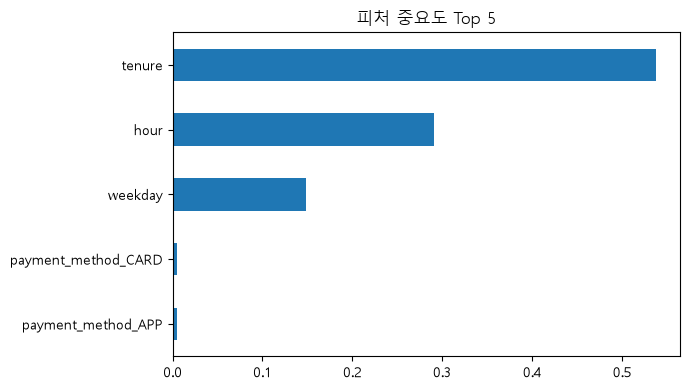

In [ ]:
# STEP 9
imp = pd.Series(rf.feature_importances_, index=X_train.columns)
top5 = imp.sort_values(ascending=False).head(5)
print(top5)

top5.sort_values().plot(kind="barh", figsize=(7, 4), title="피처 중요도 Top 5")
plt.tight_layout()
plt.show()